### CO2

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor  
from utils import eval, visual, save, save_model
import numpy as np
from sklearn.model_selection import KFold

/root/miniconda3/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [2]:
import pandas as pd
data = pd.read_csv('data/compound_6_CO2.csv').iloc[:, 1:]

X = data.iloc[:, :-1] 
y = data.iloc[:, -1].astype(float)  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

In [3]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test,  dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
y_test  = np.asarray(y_test,  dtype=np.float32).reshape(-1)


In [4]:
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, mae, rmse

def cv_score(X, y, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    r2s, maes, rmses = [], [], []
    for tr, va in kf.split(X):
        reg = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64)
        reg.fit(X[tr], y[tr])
        pred = reg.predict(X[va])
        r2, mae, rmse = metrics(y[va], pred)
        r2s.append(r2); maes.append(mae); rmses.append(rmse)
    return (
        (np.mean(r2s),  np.std(r2s)),
        (np.mean(maes), np.std(maes)),
        (np.mean(rmses),np.std(rmses))
    )

In [5]:

regressor = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64,random_state=42)  
regressor.fit(X_train, y_train)

train_pred = regressor.predict(X_train)
test_pred  = regressor.predict(X_test)

tr_r2, tr_mae, tr_rmse = metrics(y_train, train_pred)
te_r2, te_mae, te_rmse = metrics(y_test,  test_pred)

print("【Train】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(tr_r2, tr_mae, tr_rmse))
print("【Test 】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(te_r2, te_mae, te_rmse))

(cv_r2, cv_r2_std), (cv_mae, cv_mae_std), (cv_rmse, cv_rmse_std) = cv_score(X_train, y_train)
print("【CV-5】  R²={:.6f}±{:.6f} | MAE={:.6f}±{:.6f} | RMSE={:.6f}±{:.6f}".format(
    cv_r2, cv_r2_std, cv_mae, cv_mae_std, cv_rmse, cv_rmse_std
))


【Train】 R²=0.950032 | MAE=0.043809 | RMSE=0.093965
【Test 】 R²=0.897494 | MAE=0.069554 | RMSE=0.127162
【CV-5】  R²=0.893022±0.035230 | MAE=0.081590±0.012158 | RMSE=0.134633±0.023239


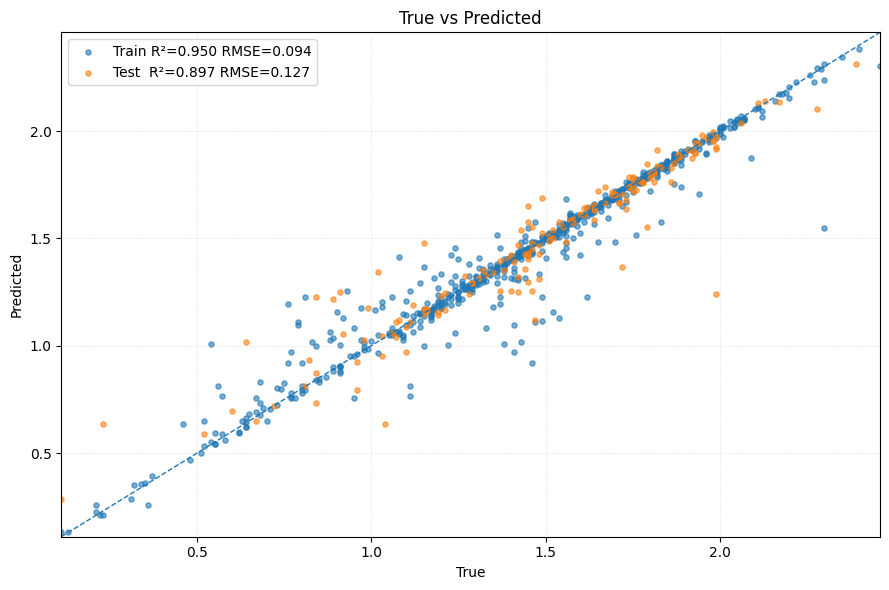

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()
p_tr = np.asarray(regressor.predict(X_train)).ravel()
p_te = np.asarray(regressor.predict(X_test)).ravel()

def r2_rmse(y, p):
    return r2_score(y, p), mean_squared_error(y, p, squared=False)

r2_tr, rmse_tr = r2_rmse(y_tr, p_tr)
r2_te, rmse_te = r2_rmse(y_te, p_te)

lo = float(min(y_tr.min(), y_te.min(), p_tr.min(), p_te.min()))
hi = float(max(y_tr.max(), y_te.max(), p_tr.max(), p_te.max()))

plt.figure(figsize=(9, 6))
plt.scatter(y_tr, p_tr, s=14, alpha=0.6, label=f"Train R²={r2_tr:.3f} RMSE={rmse_tr:.3f}")
plt.scatter(y_te, p_te, s=14, alpha=0.6, label=f"Test  R²={r2_te:.3f} RMSE={rmse_te:.3f}")
plt.plot([lo, hi], [lo, hi], '--', lw=1)  # y=x
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.legend()
plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [7]:
from pathlib import Path

df_train = pd.DataFrame({
    "split": "train",
    "row_id": np.arange(len(y_tr)),
    "y_true": y_tr,
    "y_pred": p_tr,
    "residual": y_tr - p_tr,
})
df_test = pd.DataFrame({
    "split": "test",
    "row_id": np.arange(len(y_te)),
    "y_true": y_te,
    "y_pred": p_te,
    "residual": y_te - p_te,
})
df_points = pd.concat([df_train, df_test], ignore_index=True)

out_path = Path("plots/TabPFN_CO2_6.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_points.to_csv(out_path, index=False)

print(f"Saved scatter points to: {out_path}  (rows={len(df_points)})")


Saved scatter points to: plots/TabPFN_CO2_6.csv  (rows=790)


In [12]:
import os, gc, time
import numpy as np
import pandas as pd
from tqdm import tqdm

df_new = pd.read_csv('data/compound_new_structural.csv')

CURRENT_DENSITY_VAL = 400
df_new["CurrentDensity"] = CURRENT_DENSITY_VAL
cols = [c for c in df_new.columns if c not in ("compound", "CurrentDensity")] + ["CurrentDensity"]
df_ordered = df_new[["compound"] + cols]

compounds = df_ordered['compound'].values
X_pred = df_ordered.drop(columns=['compound']).to_numpy(dtype=np.float32)

OUTER_BATCH = 2000

def _as_mean_array(out):
    if isinstance(out, dict):
        for k in ('mean', 'pred', 'prediction', 'preds'):
            if k in out:
                return np.asarray(out[k], dtype=np.float32).ravel()
        return np.asarray(out, dtype=np.float32).ravel()
    return np.asarray(out, dtype=np.float32).ravel()

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

try:
    import torch
    HAS_TORCH = torch.cuda.is_available()
except Exception:
    HAS_TORCH = False

def predict_with_microchunks(Xb, start_idx, preds,
                             init_micro=512, min_micro=1):

    n = len(Xb)
    done = 0
    micro = init_micro

    while done < n:
        end = min(done + micro, n)
        try:
            out = regressor.predict(Xb[done:end], output_type='main')
            mu = _as_mean_array(out)
            preds[start_idx + done : start_idx + end] = mu[:(end - done)]

            done = end

            if HAS_TORCH:
                try:
                    torch.cuda.synchronize()
                    torch.cuda.empty_cache()
                except Exception:
                    pass
            del out, mu
            gc.collect()
            time.sleep(0.002)

        except RuntimeError as e:
            msg = str(e).lower()
            if ('out of memory' in msg or 'cuda' in msg) and micro > min_micro:
                micro = max(min_micro, micro // 2)
                print(f"[OOM] inner micro-batch -> {micro}")
                if HAS_TORCH:
                    try:
                        torch.cuda.synchronize()
                        torch.cuda.empty_cache()
                    except Exception:
                        pass
                gc.collect()
                time.sleep(0.02)
            else:
                raise

n = len(X_pred)
preds = np.empty(n, dtype=np.float32)
print(f"[Info] pool size={n}, n_features={X_pred.shape[1]}, outer_batch={OUTER_BATCH}")

pbar = tqdm(total=n, desc="predict mean (TabPFN)", unit="row")

for i in range(0, n, OUTER_BATCH):
    end = min(i + OUTER_BATCH, n)
    Xb = X_pred[i:end]
    predict_with_microchunks(Xb, start_idx=i, preds=preds, init_micro=512, min_micro=1)
    pbar.update(end - i)

    if HAS_TORCH:
        try:
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
        except Exception:
            pass
    del Xb
    gc.collect()

pbar.close()

os.makedirs('predict', exist_ok=True)
pd.DataFrame({
    'compound': compounds,
    'predicted_mean': preds
}).to_csv('predict/tabpfn_predict_CO2_6_400.csv', index=False)

print("✅ saved 'predict/tabpfn_predict_CO2_6_400.csv'")


[Info] pool size=34005, n_features=34, outer_batch=2000


predict mean (TabPFN): 100%|██████████| 34005/34005 [05:17<00:00, 106.94row/s]

✅ saved 'predict/tabpfn_predict_CO2_6_400.csv'


### feature importance

In [6]:

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

feat_names = [
    "AB_AN","AB_AW","AB_CR","AB_AR","AB_FIE","AB_SIE","AB_EA","AB_EN","AB_Nd","AB_Nv","AB_D","AB_EC","AB_TC",
    "C_AN","C_AW","C_CR","C_AR","C_VR","C_FIE","C_SIE","C_EA","C_EN","C_Np","C_Nv","C_D",
    "a_1","b_1","c_1","Grain_1","a_2","b_2","c_2","Grain_2","CurrentDensity"
]

groups = {
    "AB_*":       [i for i,f in enumerate(feat_names) if f.startswith("AB_")],
    "C_*":        [i for i,f in enumerate(feat_names) if f.startswith("C_")],
    "Lattice_1":  [feat_names.index(n) for n in ["a_1","b_1","c_1","Grain_1"]],
    "Lattice_2":  [feat_names.index(n) for n in ["a_2","b_2","c_2","Grain_2"]],
    "CurrentDensity": [feat_names.index("CurrentDensity")]
}

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def _as_array(X):
    return X.values if hasattr(X, "values") else X

def predict_batched(model, X, batch_size=4096):
    arr = _as_array(X)
    outs = []
    for i in range(0, len(arr), batch_size):
        outs.append(model.predict(arr[i:i+batch_size]))
    return np.concatenate(outs, axis=0)

def baseline_scores(model, X, y, batch_size=4096):
    pred = predict_batched(model, X, batch_size=batch_size)
    return r2_score(y, pred), rmse(y, pred)

def make_eval_subset(X, y, max_n=1024, seed=2025):
    n = len(X)
    if n <= max_n:
        return X, y
    rng = np.random.RandomState(seed)
    idx = rng.choice(n, size=max_n, replace=False)
    if hasattr(X, "iloc"):
        X_sub = X.iloc[idx]
        y_sub = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
    else:
        X_sub = X[idx]
        y_sub = y[idx]
    return X_sub, y_sub

def permutation_importance_reg(
    model, X, y, feature_names,
    n_repeats=20, random_state=42, batch_size=4096,
    score_metric='r2',    
    normalize='minmax'    
):

    rng = np.random.RandomState(random_state)
    X_val = X.copy()
    base_r2, base_rmse = baseline_scores(model, X_val, y, batch_size=batch_size)

    rows = []
    for j, fname in enumerate(feature_names):
        rmse_increases, r2_drops = [], []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            idx = rng.permutation(len(Xp))
            if hasattr(Xp, "iloc"):
                col = Xp.columns[j]
                Xp[col] = Xp[col].values[idx]
            else:
                Xp[:, j] = Xp[idx, j]
            pred = predict_batched(model, Xp, batch_size=batch_size)
            pr_rmse = rmse(y, pred)
            pr_r2   = r2_score(y, pred)
            rmse_increases.append(pr_rmse - base_rmse)
            r2_drops.append(base_r2 - pr_r2)
        rows.append([fname,
                     np.mean(rmse_increases), np.std(rmse_increases),
                     np.mean(r2_drops),       np.std(r2_drops)])

    df = pd.DataFrame(rows, columns=[
        "feature","rmse_increase_mean","rmse_increase_std","r2_drop_mean","r2_drop_std"
    ])

    if score_metric == 'rmse':
        v = df["rmse_increase_mean"].values
        std = df["rmse_increase_std"].values
    else:
        v = df["r2_drop_mean"].values
        std = df["r2_drop_std"].values

    eps = 1e-12
    if normalize == 'share':
        score = v / (v.sum() + eps)
    else:
        score = (v - v.min()) / (v.max() - v.min() + eps)

    snr = v / (std + eps)

    df["score"] = score
    df["snr"] = snr
    df = df.sort_values(["score","snr"], ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df)+1)
    return df, (base_r2, base_rmse)

def grouped_permutation_importance_reg(
    model, X, y, groups, n_repeats=32, random_state=42,
    score_metric='r2',      
    normalize='minmax',     
    batch_size=4096
):

    rng = np.random.RandomState(random_state)
    X_val = X.copy()
    base_r2, base_rmse = baseline_scores(model, X_val, y, batch_size=batch_size)

    rows = []
    for gname, gcols in groups.items():
        rmse_increases, r2_drops = [], []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            idx = rng.permutation(len(Xp))
            if hasattr(Xp, "iloc"):
                cols = [Xp.columns[c] for c in gcols]
                Xp[cols] = Xp[cols].values[idx]
            else:
                Xp[:, gcols] = Xp[idx][:, gcols]
            pred = predict_batched(model, Xp, batch_size=batch_size)
            pr_rmse = rmse(y, pred)
            pr_r2   = r2_score(y, pred)
            rmse_increases.append(pr_rmse - base_rmse)
            r2_drops.append(base_r2 - pr_r2)
        rows.append([gname, np.mean(rmse_increases), np.std(rmse_increases),
                     np.mean(r2_drops), np.std(r2_drops), len(gcols)])

    df = pd.DataFrame(rows, columns=[
        "group","rmse_increase_mean","rmse_increase_std",
        "r2_drop_mean","r2_drop_std","size"
    ])

    if score_metric == 'rmse':
        v = df["rmse_increase_mean"].values
        std = df["rmse_increase_std"].values
    else:
        v = df["r2_drop_mean"].values
        std = df["r2_drop_std"].values

    eps = 1e-12
    if normalize == 'share':
        score = v / (v.sum() + eps)
    else:
        score = (v - v.min()) / (v.max() - v.min() + eps)

    per_feature = v / (df["size"].values + eps)
    snr = v / (std + eps)

    df["score"] = score
    df["per_feature"] = per_feature
    df["snr"] = snr
    df = df.sort_values(["score","snr"], ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df)+1)
    return df, (base_r2, base_rmse)

if __name__ == "__main__":

    X_eval, y_eval = make_eval_subset(X_test, y_test, max_n=1024, seed=2025)

    print(">>> Computing per-feature permutation importance ...")
    perm_df, base = permutation_importance_reg(
        regressor, X_eval, y_eval, feat_names,
        n_repeats=16,              
        random_state=11,
        batch_size=4096,
        score_metric='r2',         
        normalize='minmax'          
    )
    print(perm_df.head(15).to_string(index=False))
    perm_df.to_csv("perm_feature_importance.csv", index=False)
    print("Saved: perm_feature_importance.csv")

    print("\n>>> Computing grouped permutation importance ...")
    gperm_df, _ = grouped_permutation_importance_reg(
        regressor, X_eval, y_eval, groups,
        n_repeats=16,               
        random_state=12,
        batch_size=4096,
        score_metric='r2',
        normalize='minmax'
    )
    print(gperm_df.to_string(index=False))
    gperm_df.to_csv("perm_group_importance.csv", index=False)
    print("Saved: perm_group_importance.csv")



>>> Computing per-feature permutation importance ...
       feature  rmse_increase_mean  rmse_increase_std  r2_drop_mean  r2_drop_std    score       snr  rank
CurrentDensity            0.244275           0.014573      0.773428     0.067135 1.000000 11.520572     1
           c_1            0.055569           0.006265      0.109412     0.014432 0.139508  7.581333     2
       Grain_1            0.042977           0.005692      0.081202     0.012283 0.102952  6.611165     3
         AB_Nd            0.031178           0.003722      0.056515     0.007475 0.070961  7.560500     4
         AB_Nv            0.017290           0.004065      0.029875     0.007438 0.036437  4.016565     5
         AB_AW            0.017065           0.002702      0.029404     0.004972 0.035828  5.914142     6
         AB_EA            0.016780           0.002663      0.028884     0.004833 0.035153  5.976326     7
         AB_EC            0.011449           0.002405      0.019325     0.004236 0.022767  4.561760

In [7]:
import numpy as np
import pandas as pd
from copy import deepcopy
from sklearn.metrics import r2_score

lattice1_names = ["a_1","b_1","c_1","Grain_1"]
lattice1_idx = [feat_names.index(n) for n in lattice1_names]

def permutation_importance_subset(
    model, X, y,
    all_feature_names, subset_names,
    n_repeats=32, random_state=2025, batch_size=4096,
    score_metric='r2', normalize='minmax'
):
    rng = np.random.RandomState(random_state)
    X_val = X.copy()
    base_r2, base_rmse = baseline_scores(model, X_val, y, batch_size=batch_size)

    rows = []
    name2idx = {f:i for i,f in enumerate(all_feature_names)}
    for fname in subset_names:
        j = name2idx[fname]
        rmse_increases, r2_drops = [], []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            idx = rng.permutation(len(Xp))
            if hasattr(Xp, "iloc"):
                col = Xp.columns[j]
                Xp[col] = Xp[col].values[idx]
            else:
                Xp[:, j] = Xp[idx, j]
            pred = predict_batched(model, Xp, batch_size=batch_size)
            pr_rmse = rmse(y, pred)
            pr_r2   = r2_score(y, pred)
            rmse_increases.append(pr_rmse - base_rmse)
            r2_drops.append(base_r2 - pr_r2)
        rows.append([fname,
                     np.mean(rmse_increases), np.std(rmse_increases),
                     np.mean(r2_drops),       np.std(r2_drops)])
    df = pd.DataFrame(rows, columns=["feature","rmse_increase_mean","rmse_increase_std","r2_drop_mean","r2_drop_std"])

    if score_metric == 'rmse':
        v, s = df["rmse_increase_mean"].values, df["rmse_increase_std"].values
    else:
        v, s = df["r2_drop_mean"].values, df["r2_drop_std"].values
    eps = 1e-12
    score = (v / (v.sum()+eps)) if normalize=='share' else (v - v.min())/(v.max()-v.min()+eps)
    snr = v / (s + eps)

    df["score"] = score
    df["snr"] = snr
    df = df.sort_values(["score","snr"], ascending=False).reset_index(drop=True)
    return df

X_eval, y_eval = make_eval_subset(X_test, y_test, max_n=1024, seed=2025)

lattice1_perm_df = permutation_importance_subset(
    regressor, X_eval, y_eval,
    feat_names, lattice1_names,
    n_repeats=32, random_state=2026, batch_size=4096,
    score_metric='r2', normalize='minmax'
)

print("\n=== Lattice_1: per-feature permutation importance ===")
print(lattice1_perm_df.to_string(index=False))
lattice1_perm_df.to_csv("lattice1_perm_importance.csv", index=False)



=== Lattice_1: per-feature permutation importance ===
feature  rmse_increase_mean  rmse_increase_std  r2_drop_mean  r2_drop_std    score      snr
    c_1            0.052818           0.005950      0.103064     0.013649 1.000000 7.550788
Grain_1            0.044014           0.006942      0.083546     0.015116 0.784690 5.527119
    a_1            0.007582           0.001834      0.012609     0.003124 0.002125 4.036852
    b_1            0.007469           0.001860      0.012417     0.003176 0.000000 3.909652


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from copy import deepcopy

def rmse(y, yhat): 
    from sklearn.metrics import mean_squared_error
    return np.sqrt(mean_squared_error(y, yhat))

def loco_importance(regressor, X_train, y_train, X_test, y_test, feat_names):
    base_model = deepcopy(regressor)
    base_model.fit(X_train, y_train)
    base_r2 = r2_score(y_test, base_model.predict(X_test))
    base_rmse = rmse(y_test, base_model.predict(X_test))

    rows = []
    for j, f in enumerate(feat_names):
        if hasattr(X_train, 'drop'):
            Xtr = X_train.drop(columns=[f])
            Xte = X_test.drop(columns=[f])
        else:
            Xtr = np.delete(X_train, j, axis=1)
            Xte = np.delete(X_test,  j, axis=1)

        m = deepcopy(regressor)
        m.fit(Xtr, y_train)
        pred = m.predict(Xte)
        r2 = r2_score(y_test, pred)
        e  = rmse(y_test, pred)

        rows.append([f, base_rmse - e, r2 - base_r2])  
    df = pd.DataFrame(rows, columns=["feature","delta_rmse(+)","delta_r2(+)"])
    v = (base_rmse - (base_rmse - df["delta_rmse(+)"]))  
    v = df["delta_rmse(+)"].values
    eps=1e-12
    df["score"]=(v - v.min())/(v.max()-v.min()+eps)
    return df.sort_values("score", ascending=False).reset_index(drop=True)

loco_df = loco_importance(regressor, X_train, y_train, X_test, y_test, feat_names)
print(loco_df.head(15).to_string(index=False))


feature  delta_rmse(+)  delta_r2(+)    score
  AB_Nd       0.001764     0.002825 1.000000
  AB_EC       0.001664     0.002665 0.999459
 AB_FIE       0.000738     0.001187 0.994476
  AB_TC       0.000726     0.001168 0.994411
    b_1       0.000600     0.000964 0.993727
Grain_2       0.000542     0.000872 0.993417
  AB_AW       0.000269     0.000434 0.991950
  AB_AN       0.000243     0.000391 0.991808
  AB_AR       0.000142     0.000229 0.991264
   AB_D      -0.000121    -0.000196 0.989846
   C_Nv      -0.000330    -0.000533 0.988723
   C_Np      -0.000467    -0.000754 0.987985
  AB_EN      -0.000579    -0.000935 0.987383
  AB_EA      -0.000640    -0.001035 0.987051
   C_CR      -0.000766    -0.001238 0.986375


### O2

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor  
from utils import eval, visual, save, save_model
import numpy as np
from sklearn.model_selection import KFold

/root/miniconda3/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [2]:
import pandas as pd
data = pd.read_csv('data/compound_6_O2.csv').iloc[:, 1:]

X = data.iloc[:, :-1]  
y = data.iloc[:, -1].astype(float)  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test,  dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
y_test  = np.asarray(y_test,  dtype=np.float32).reshape(-1)

In [7]:
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, mae, rmse

def cv_score(X, y, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    r2s, maes, rmses = [], [], []
    for tr, va in kf.split(X):
        reg = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64)
        reg.fit(X[tr], y[tr])
        pred = reg.predict(X[va])
        r2, mae, rmse = metrics(y[va], pred)
        r2s.append(r2); maes.append(mae); rmses.append(rmse)
    return (
        (np.mean(r2s),  np.std(r2s)),
        (np.mean(maes), np.std(maes)),
        (np.mean(rmses),np.std(rmses))
    )

In [8]:

regressor = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64,random_state=42)  
regressor.fit(X_train, y_train)

train_pred = regressor.predict(X_train)
test_pred  = regressor.predict(X_test)

tr_r2, tr_mae, tr_rmse = metrics(y_train, train_pred)
te_r2, te_mae, te_rmse = metrics(y_test,  test_pred)

print("【Train】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(tr_r2, tr_mae, tr_rmse))
print("【Test 】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(te_r2, te_mae, te_rmse))

(cv_r2, cv_r2_std), (cv_mae, cv_mae_std), (cv_rmse, cv_rmse_std) = cv_score(X_train, y_train)
print("【CV-5】  R²={:.6f}±{:.6f} | MAE={:.6f}±{:.6f} | RMSE={:.6f}±{:.6f}".format(
    cv_r2, cv_r2_std, cv_mae, cv_mae_std, cv_rmse, cv_rmse_std
))


【Train】 R²=0.945931 | MAE=0.044650 | RMSE=0.089057
【Test 】 R²=0.821067 | MAE=0.088283 | RMSE=0.178772
【CV-5】  R²=0.856638±0.033573 | MAE=0.084254±0.014256 | RMSE=0.143921±0.019102


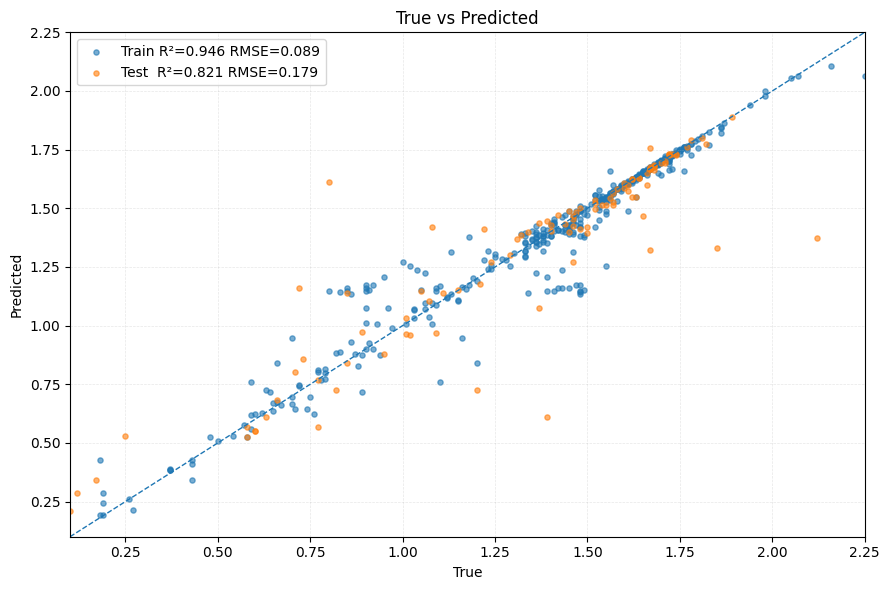

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()
p_tr = np.asarray(regressor.predict(X_train)).ravel()
p_te = np.asarray(regressor.predict(X_test)).ravel()

def r2_rmse(y, p):
  return r2_score(y, p), np.sqrt(mean_squared_error(y, p))

r2_tr, rmse_tr = r2_rmse(y_tr, p_tr)
r2_te, rmse_te = r2_rmse(y_te, p_te)

lo = float(min(y_tr.min(), y_te.min(), p_tr.min(), p_te.min()))
hi = float(max(y_tr.max(), y_te.max(), p_tr.max(), p_te.max()))

plt.figure(figsize=(9, 6))
plt.scatter(y_tr, p_tr, s=14, alpha=0.6, label=f"Train R²={r2_tr:.3f} RMSE={rmse_tr:.3f}")
plt.scatter(y_te, p_te, s=14, alpha=0.6, label=f"Test  R²={r2_te:.3f} RMSE={rmse_te:.3f}")
plt.plot([lo, hi], [lo, hi], '--', lw=1)  # y=x
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.legend()
plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [7]:
# === Save scatter points for external plotting ===
from pathlib import Path

# 组织为一个 DataFrame
df_train = pd.DataFrame({
    "split": "train",
    "row_id": np.arange(len(y_tr)),
    "y_true": y_tr,
    "y_pred": p_tr,
    "residual": y_tr - p_tr,
})
df_test = pd.DataFrame({
    "split": "test",
    "row_id": np.arange(len(y_te)),
    "y_true": y_te,
    "y_pred": p_te,
    "residual": y_te - p_te,
})
df_points = pd.concat([df_train, df_test], ignore_index=True)

out_path = Path("plots/TabPFN_O2_6.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_points.to_csv(out_path, index=False)

print(f"Saved scatter points to: {out_path}  (rows={len(df_points)})")


Saved scatter points to: plots/TabPFN_O2_6.csv  (rows=530)


In [12]:
import os, gc, time
import numpy as np
import pandas as pd
from tqdm import tqdm

df_new = pd.read_csv('data/compound_new_structural.csv')

CURRENT_DENSITY_VAL = 500
df_new["CurrentDensity"] = CURRENT_DENSITY_VAL
cols = [c for c in df_new.columns if c not in ("compound", "CurrentDensity")] + ["CurrentDensity"]
df_ordered = df_new[["compound"] + cols]

compounds = df_ordered['compound'].values
X_pred = df_ordered.drop(columns=['compound']).to_numpy(dtype=np.float32)

OUTER_BATCH = 2000

def _as_mean_array(out):
    if isinstance(out, dict):
        for k in ('mean', 'pred', 'prediction', 'preds'):
            if k in out:
                return np.asarray(out[k], dtype=np.float32).ravel()
        return np.asarray(out, dtype=np.float32).ravel()
    return np.asarray(out, dtype=np.float32).ravel()

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

try:
    import torch
    HAS_TORCH = torch.cuda.is_available()
except Exception:
    HAS_TORCH = False

def predict_with_microchunks(Xb, start_idx, preds,
                             init_micro=512, min_micro=1):

    n = len(Xb)
    done = 0
    micro = init_micro

    while done < n:
        end = min(done + micro, n)
        try:
            out = regressor.predict(Xb[done:end], output_type='main')
            mu = _as_mean_array(out)
            preds[start_idx + done : start_idx + end] = mu[:(end - done)]

            done = end

            if HAS_TORCH:
                try:
                    torch.cuda.synchronize()
                    torch.cuda.empty_cache()
                except Exception:
                    pass
            del out, mu
            gc.collect()
            time.sleep(0.002)

        except RuntimeError as e:
            msg = str(e).lower()
            if ('out of memory' in msg or 'cuda' in msg) and micro > min_micro:
                micro = max(min_micro, micro // 2)
                print(f"[OOM] inner micro-batch -> {micro}")
                if HAS_TORCH:
                    try:
                        torch.cuda.synchronize()
                        torch.cuda.empty_cache()
                    except Exception:
                        pass
                gc.collect()
                time.sleep(0.02)
            else:
                raise

n = len(X_pred)
preds = np.empty(n, dtype=np.float32)
print(f"[Info] pool size={n}, n_features={X_pred.shape[1]}, outer_batch={OUTER_BATCH}")

pbar = tqdm(total=n, desc="predict mean (TabPFN)", unit="row")

for i in range(0, n, OUTER_BATCH):
    end = min(i + OUTER_BATCH, n)
    Xb = X_pred[i:end]
    predict_with_microchunks(Xb, start_idx=i, preds=preds, init_micro=512, min_micro=1)
    pbar.update(end - i)

    if HAS_TORCH:
        try:
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
        except Exception:
            pass
    del Xb
    gc.collect()

pbar.close()

os.makedirs('predict', exist_ok=True)
pd.DataFrame({
    'compound': compounds,
    'predicted_mean': preds
}).to_csv('predict/tabpfn_predict_O2_6_500.csv', index=False)

print("✅ saved 'predict/tabpfn_predict_O2_6_500.csv'")


[Info] pool size=34005, n_features=34, outer_batch=2000


predict mean (TabPFN): 100%|██████████| 34005/34005 [07:15<00:00, 78.11row/s] 


✅ saved 'predict/tabpfn_predict_O2_6_500.csv'


In [ ]:


import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

feat_names = [
    "AB_AN","AB_AW","AB_CR","AB_AR","AB_FIE","AB_SIE","AB_EA","AB_EN","AB_Nd","AB_Nv","AB_D","AB_EC","AB_TC",
    "C_AN","C_AW","C_CR","C_AR","C_VR","C_FIE","C_SIE","C_EA","C_EN","C_Np","C_Nv","C_D",
    "a_1","b_1","c_1","Grain_1","a_2","b_2","c_2","Grain_2","CurrentDensity"
]

groups = {
    "AB_*":       [i for i,f in enumerate(feat_names) if f.startswith("AB_")],
    "C_*":        [i for i,f in enumerate(feat_names) if f.startswith("C_")],
    "Lattice_1":  [feat_names.index(n) for n in ["a_1","b_1","c_1","Grain_1"]],
    "Lattice_2":  [feat_names.index(n) for n in ["a_2","b_2","c_2","Grain_2"]],
    "CurrentDensity": [feat_names.index("CurrentDensity")]
}

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def _as_array(X):
    return X.values if hasattr(X, "values") else X

def predict_batched(model, X, batch_size=4096):
    arr = _as_array(X)
    outs = []
    for i in range(0, len(arr), batch_size):
        outs.append(model.predict(arr[i:i+batch_size]))
    return np.concatenate(outs, axis=0)

def baseline_scores(model, X, y, batch_size=4096):
    pred = predict_batched(model, X, batch_size=batch_size)
    return r2_score(y, pred), rmse(y, pred)

def make_eval_subset(X, y, max_n=1024, seed=2025):
    n = len(X)
    if n <= max_n:
        return X, y
    rng = np.random.RandomState(seed)
    idx = rng.choice(n, size=max_n, replace=False)
    if hasattr(X, "iloc"):
        X_sub = X.iloc[idx]
        y_sub = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
    else:
        X_sub = X[idx]
        y_sub = y[idx]
    return X_sub, y_sub

def permutation_importance_reg(
    model, X, y, feature_names,
    n_repeats=20, random_state=42, batch_size=4096,
    score_metric='r2',    
    normalize='minmax'     
):

    rng = np.random.RandomState(random_state)
    X_val = X.copy()
    base_r2, base_rmse = baseline_scores(model, X_val, y, batch_size=batch_size)

    rows = []
    for j, fname in enumerate(feature_names):
        rmse_increases, r2_drops = [], []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            idx = rng.permutation(len(Xp))
            if hasattr(Xp, "iloc"):
                col = Xp.columns[j]
                Xp[col] = Xp[col].values[idx]
            else:
                Xp[:, j] = Xp[idx, j]
            pred = predict_batched(model, Xp, batch_size=batch_size)
            pr_rmse = rmse(y, pred)
            pr_r2   = r2_score(y, pred)
            rmse_increases.append(pr_rmse - base_rmse)
            r2_drops.append(base_r2 - pr_r2)
        rows.append([fname,
                     np.mean(rmse_increases), np.std(rmse_increases),
                     np.mean(r2_drops),       np.std(r2_drops)])

    df = pd.DataFrame(rows, columns=[
        "feature","rmse_increase_mean","rmse_increase_std","r2_drop_mean","r2_drop_std"
    ])

    if score_metric == 'rmse':
        v = df["rmse_increase_mean"].values
        std = df["rmse_increase_std"].values
    else:
        v = df["r2_drop_mean"].values
        std = df["r2_drop_std"].values

    eps = 1e-12
    if normalize == 'share':
        score = v / (v.sum() + eps)
    else:
        score = (v - v.min()) / (v.max() - v.min() + eps)

    snr = v / (std + eps)

    df["score"] = score
    df["snr"] = snr
    df = df.sort_values(["score","snr"], ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df)+1)
    return df, (base_r2, base_rmse)

def grouped_permutation_importance_reg(
    model, X, y, groups, n_repeats=32, random_state=42,
    score_metric='r2',     
    normalize='minmax',     
    batch_size=4096
):

    rng = np.random.RandomState(random_state)
    X_val = X.copy()
    base_r2, base_rmse = baseline_scores(model, X_val, y, batch_size=batch_size)

    rows = []
    for gname, gcols in groups.items():
        rmse_increases, r2_drops = [], []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            idx = rng.permutation(len(Xp))
            if hasattr(Xp, "iloc"):
                cols = [Xp.columns[c] for c in gcols]
                Xp[cols] = Xp[cols].values[idx]
            else:
                Xp[:, gcols] = Xp[idx][:, gcols]
            pred = predict_batched(model, Xp, batch_size=batch_size)
            pr_rmse = rmse(y, pred)
            pr_r2   = r2_score(y, pred)
            rmse_increases.append(pr_rmse - base_rmse)
            r2_drops.append(base_r2 - pr_r2)
        rows.append([gname, np.mean(rmse_increases), np.std(rmse_increases),
                     np.mean(r2_drops), np.std(r2_drops), len(gcols)])

    df = pd.DataFrame(rows, columns=[
        "group","rmse_increase_mean","rmse_increase_std",
        "r2_drop_mean","r2_drop_std","size"
    ])

    if score_metric == 'rmse':
        v = df["rmse_increase_mean"].values
        std = df["rmse_increase_std"].values
    else:
        v = df["r2_drop_mean"].values
        std = df["r2_drop_std"].values

    eps = 1e-12
    if normalize == 'share':
        score = v / (v.sum() + eps)
    else:
        score = (v - v.min()) / (v.max() - v.min() + eps)

    per_feature = v / (df["size"].values + eps)
    snr = v / (std + eps)

    df["score"] = score
    df["per_feature"] = per_feature
    df["snr"] = snr
    df = df.sort_values(["score","snr"], ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df)+1)
    return df, (base_r2, base_rmse)

if __name__ == "__main__":

    X_eval, y_eval = make_eval_subset(X_test, y_test, max_n=1024, seed=2025)

    print(">>> Computing per-feature permutation importance ...")
    perm_df, base = permutation_importance_reg(
        regressor, X_eval, y_eval, feat_names,
        n_repeats=16,               
        random_state=11,
        batch_size=4096,
        score_metric='r2',          
        normalize='minmax'          
    )
    print(perm_df.head(15).to_string(index=False))
    perm_df.to_csv("perm_feature_importance_O2.csv", index=False)
    print("Saved: perm_feature_importance_O2.csv")

    print("\n>>> Computing grouped permutation importance ...")
    gperm_df, _ = grouped_permutation_importance_reg(
        regressor, X_eval, y_eval, groups,
        n_repeats=16,               
        random_state=12,
        batch_size=4096,
        score_metric='r2',
        normalize='minmax'
    )
    print(gperm_df.to_string(index=False))
    gperm_df.to_csv("perm_group_importance_O2.csv", index=False)
    print("Saved: perm_group_importance_O2.csv")



>>> Computing per-feature permutation importance ...
